<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/HousePricePredictionAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing Pricing (Original Dataset + Imports Initialization)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [ ]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['PRICE'] = housing.target

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
x = data.drop('PRICE', axis=1)
y = data['PRICE']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 0.5558915986952444
Root Mean Squared Error: 0.7455813830127764


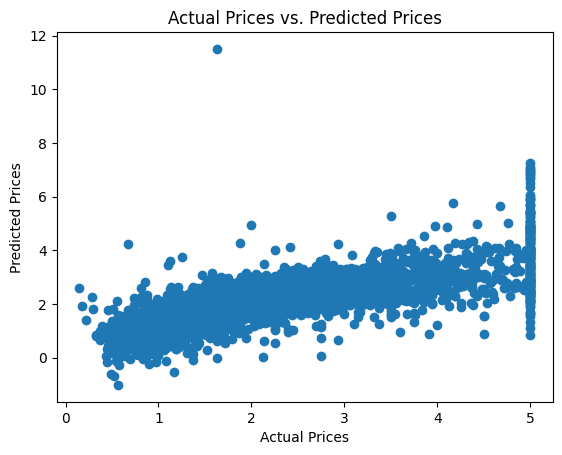

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()

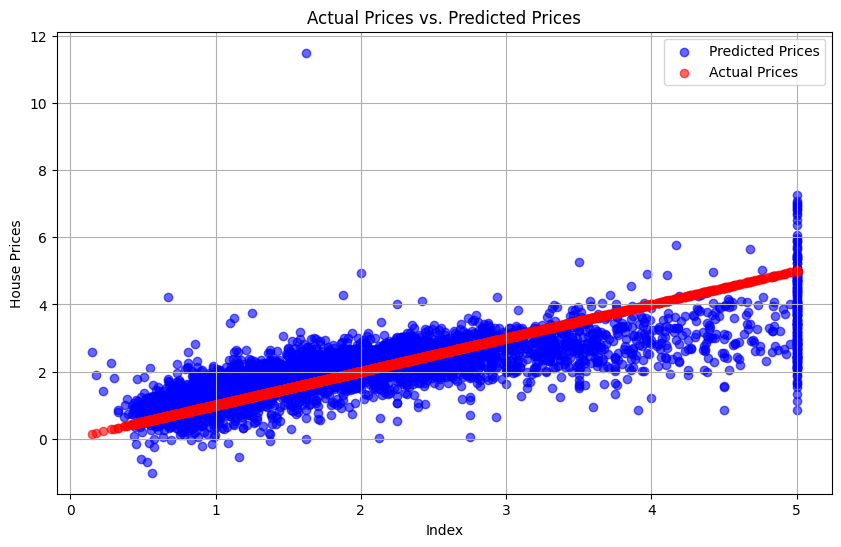

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color = 'blue', label = 'Predicted Prices', alpha=0.6) # Predicted Prices
plt.scatter(y_test, y_test, color = 'red', label = 'Actual Prices', alpha=0.6) # Actual Prices
plt.xlabel("Index")
plt.ylabel("House Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.legend()
plt.grid()
plt.show()

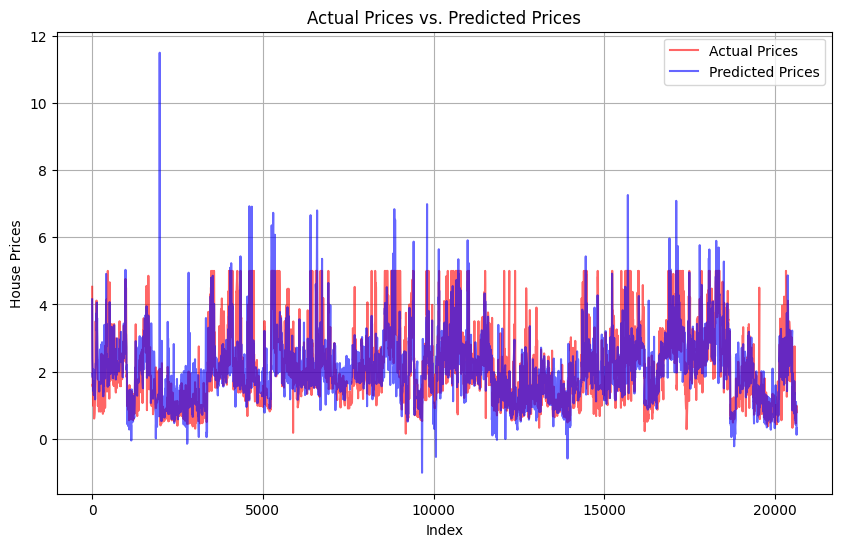

In [ ]:
# Create a DataFrame for better visualization
results = pd.DataFrame({'Actual Prices': y_test, 'Predicted Prices': y_pred})

# Sort by actual values for better line plotting
results.sort_index(inplace=True)

# Plot the actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(results.index, results['Actual Prices'], color = 'red', label = 'Actual Prices', alpha=0.6) # Actual Prices
plt.plot(results.index, results['Predicted Prices'], color = 'blue', label = 'Predicted Prices', alpha=0.6) # Predicted Prices
plt.xlabel("Index")
plt.ylabel("House Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Sorting the DataFrame by actual values for better visibility
results_sorted = results.sort_values(by='Actual Prices').reset_index(drop=True)
print(results_sorted)

      Actual Prices  Predicted Prices
0           0.14999          2.584993
1           0.17500          1.908291
2           0.22500          1.417831
3           0.28300          2.269281
4           0.30000          1.803414
...             ...               ...
4123        5.00001          6.357260
4124        5.00001          5.430905
4125        5.00001          6.801288
4126        5.00001          5.359252
4127        5.00001          4.010686

[4128 rows x 2 columns]


# UK Housing Prices (New Dataset)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset


In [ ]:
import os
import pandas as pd

# List files in the downloaded directory to find the correct CSV file name
print(os.listdir(path))

# Assuming the CSV file is named 'Housing.csv' based on the output
# Load the dataset
new_data_path = os.path.join(path, 'Housing.csv')
NewHousing = pd.read_csv(new_data_path)

# Display the first few rows
display(new_data.head())

['Housing.csv']


NameError: name 'new_data' is not defined

In [ ]:
# Identify categorical columns
categorical_cols = NewHousing.select_dtypes(include=['object']).columns

# Apply one-hot encoding
NewHousing_encoded = pd.get_dummies(NewHousing, columns=categorical_cols, drop_first=True)

# Update x_new with the encoded data, excluding the target variable 'price'
x_new = NewHousing_encoded.drop('price', axis=1)

# Display the first few rows of the updated x_new
display(x_new.head())

In [ ]:
# Define features (X) and target (y) for the new dataset
x_new = NewHousing.drop('price', axis=1)
y_new = NewHousing['price']

print("New data features shape:", x_new.shape)
print("New data target shape:", y_new.shape)

In [ ]:
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(x_new, y_new, test_size=0.3, random_state=42)

print("New training data shape:", x_train_new.shape)
print("New testing data shape:", x_test_new.shape)

In [ ]:
# Identify categorical columns
categorical_cols = x_train_new.select_dtypes(include=['object']).columns

# Apply one-hot encoding to the training data
x_train_new_encoded = pd.get_dummies(x_train_new, columns=categorical_cols, drop_first=True)

# Apply one-hot encoding to the testing data
x_test_new_encoded = pd.get_dummies(x_test_new, columns=categorical_cols, drop_first=True)

print("Shape of encoded training data:", x_train_new_encoded.shape)
print("Shape of encoded testing data:", x_test_new_encoded.shape)

In [ ]:
model_new = LinearRegression()
model_new.fit(x_train_new_encoded, y_train_new)

In [ ]:
y_pred_new = model_new.predict(x_test_new_encoded)

mse_new = mean_squared_error(y_test_new, y_pred_new)
print("Mean Squared Error (New Dataset):", mse_new)

rmse_new = np.sqrt(mse_new)
print("Root Mean Squared Error (New Dataset):", rmse_new)

In [ ]:
plt.scatter(y_test_new, y_pred_new)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_new, y_pred_new, color = 'blue', label = 'Predicted Prices', alpha=0.6) # Predicted Prices
plt.scatter(y_test_new, y_test_new, color = 'red', label = 'Actual Prices', alpha=0.6) # Actual Prices
plt.xlabel("Index")
plt.ylabel("House Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Create a DataFrame for better visualization
results = pd.DataFrame({'Actual Prices': y_test_new, 'Predicted Prices': y_pred_new})

# Sort by actual values for better line plotting
results.sort_index(inplace=True)

# Plot the actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(results.index, results['Actual Prices'], color = 'red', label = 'Actual Prices', alpha=0.6) # Actual Prices
plt.plot(results.index, results['Predicted Prices'], color = 'blue', label = 'Predicted Prices', alpha=0.6) # Predicted Prices
plt.xlabel("Index")
plt.ylabel("House Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Sorting the DataFrame by actual values for better visibility
results_sorted = results.sort_values(by='Actual Prices').reset_index(drop=True)
print(results_sorted)

# Moscow Housing Prices

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("egorkainov/moscow-housing-price-dataset")

print("Path to dataset files:", path)

100%|██████████| 343k/343k [00:00<00:00, 725kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/egorkainov/moscow-housing-price-dataset/versions/1


In [ ]:
import os
import pandas as pd

# List files in the downloaded directory to find the correct CSV file name
print(os.listdir(path))

# Load the dataset
moscow_data_path = os.path.join(path, 'data.csv')
MoscowHousing = pd.read_csv(moscow_data_path)

# Display the first few rows
display(MoscowHousing.head())

In [ ]:
# Define features (X) and target (y) for the new dataset
x_moscow = MoscowHousing.drop('Price', axis=1)
y_moscow = MoscowHousing['Price']

print("New data features shape:", x_new.shape)
print("New data target shape:", y_new.shape)

In [ ]:
x_train_moscow, x_test_moscow, y_train_moscow, y_test_moscow = train_test_split(x_moscow, y_moscow, test_size=0.2, random_state=42)

print("New training data shape:", x_train_moscow.shape)
print("New testing data shape:", x_test_moscow.shape)

In [ ]:
# Identify categorical columns in the Moscow dataset
categorical_cols_moscow = x_moscow.select_dtypes(include=['object']).columns

# Apply one-hot encoding to the Moscow dataset
x_moscow_encoded = pd.get_dummies(x_moscow, columns=categorical_cols_moscow, drop_first=True)

print("Shape of encoded Moscow data:", x_moscow_encoded.shape)

In [ ]:
x_train_moscow_encoded, x_test_moscow_encoded, y_train_moscow, y_test_moscow = train_test_split(x_moscow_encoded, y_moscow, test_size=0.2, random_state=42)

print("Encoded Moscow training data shape:", x_train_moscow_encoded.shape)
print("Encoded Moscow testing data shape:", x_test_moscow_encoded.shape)

In [ ]:
model_moscow = LinearRegression()
model_moscow.fit(x_train_moscow_encoded, y_train_moscow)

In [ ]:
y_pred_moscow = model_moscow.predict(x_test_moscow_encoded)

mse_moscow = mean_squared_error(y_test_moscow, y_pred_moscow)
print("Mean Squared Error (Moscow Dataset):", mse_moscow)

rmse_moscow = np.sqrt(mse_moscow)
print("Root Mean Squared Error (Moscow Dataset):", rmse_moscow)

In [ ]:
# The prediction step will be added before this cell
plt.scatter(y_test_moscow, y_pred_moscow)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_moscow, y_pred_moscow, color = 'blue', label = 'Predicted Prices', alpha=0.6) # Predicted Prices
plt.scatter(y_test_moscow, y_test_moscow, color = 'red', label = 'Actual Prices', alpha=0.6) # Actual Prices
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices (Moscow Dataset)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Create a DataFrame for better visualization
results = pd.DataFrame({'Actual Prices': y_test_moscow, 'Predicted Prices': y_pred_moscow})

# Sort by actual values for better line plotting
results.sort_index(inplace=True)

# Plot the actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(results.index, results['Actual Prices'], color = 'red', label = 'Actual Prices', alpha=0.6) # Actual Prices
plt.plot(results.index, results['Predicted Prices'], color = 'blue', label = 'Predicted Prices', alpha=0.6) # Predicted Prices
plt.xlabel("Index")
plt.ylabel("House Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Sorting the DataFrame by actual values for better visibility
results_sorted = results.sort_values(by='Actual Prices').reset_index(drop=True)
print(results_sorted)